# 04 One missing rating, twice the solar

*CORE*

**Question:** What does a feeder's thermal limit rest on?

- Declare a 12.47 kV, 1 km feeder with a 100 kW load and test it with the line rating omitted, then with 200 A stated.
- Check refusal on the missing rating, solve thermal hosting capacity with 200 A, and compare both against plain OpenDSS.
- Feeder thermal capacity is not a utility line rating, equipment acceptance, or an interconnection study.

## ⚙ Setup — Initialize the teaching environment

Run the setup cell once to load helpers and check runtime dependencies.

In [1]:
#@title 1. Setup — run once
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "7707385fd5fe60a9bec2e0bdd1bda33bc7b06bab71a8304dff0a7de86d23a0c6":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0


Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## 🧩 Inputs — Declare the line rating scenarios

Declare a 12.47 kV, 1 km feeder and write two Case files: one with the line rating omitted, and one stating 200 A.

In [2]:
#@title 2. Inputs — feeder and line rating scenarios
import json
from pathlib import Path

def _thermal_case(mode: str, normal_amps: float | None, criterion: str = "thermal") -> dict:
    line = {
        "name": "line1",
        "from_bus": "sourcebus",
        "to_bus": "load",
        "length_km": 1.0,
        "r1_ohm_per_km": 0.2,
        "x1_ohm_per_km": 0.4,
        "r0_ohm_per_km": 0.6,
        "x0_ohm_per_km": 1.2,
        "b1_us_per_km": 0.0,
    }
    if normal_amps is not None:
        line["normal_amps"] = normal_amps
    return {
        "meta": {"name": "thermal-probe", "mode": mode},
        "network": {
            "kind": "inline",
            "frequency_hz": 60,
            "inline": {
                "buses": [
                    {"name": "sourcebus", "kv": 12.47, "phases": 3},
                    {"name": "load", "kv": 12.47, "phases": 3},
                ],
                "lines": [line],
                "loads": [{"id": "load1", "bus": "load", "phases": 3, "kw": 100.0, "pf": 0.95}],
                "external_grids": [
                    {
                        "name": "grid",
                        "bus": "sourcebus",
                        "pu": 1.0,
                        "angle_deg": 0.0,
                        "sk3_mva": 1000.0,
                        "sk1_mva": 1000.0,
                        "x_r_ratio": 10.0,
                    }
                ],
            },
        },
        "study": {
            "type": "hosting_capacity",
            "options": {"criterion": criterion, "buses": ["load"], "max_kw": 15000.0},
        },
    }

cases_dir = WORKSPACE / "cases"
cases_dir.mkdir(parents=True, exist_ok=True)
(cases_dir / "rating-missing.json").write_text(
    json.dumps(_thermal_case("research", None), indent=2), encoding="utf-8"
)
(cases_dir / "rating-200a.json").write_text(
    json.dumps(_thermal_case("research", 200.0), indent=2), encoding="utf-8"
)

table(
    ["declared input", "value", "unit"],
    [
        ("voltage", 12.47, "kV"),
        ("line length", 1.0, "km"),
        ("line positive-sequence impedance", "0.2 + j0.4", "ohm/km"),
        ("connected load", "100 kW @ 0.95 pf", "kW / pf"),
        ("case rating-missing line rating", "omitted", "A"),
        ("case rating-200a line rating", 200.0, "A"),
        ("study criterion", "thermal", "text"),
        ("max search PV", 15000.0, "kW"),
    ],
)


declared input                    value             unit
--------------------------------  ----------------  -------
voltage                           12.47             kV
line length                       1.0               km
line positive-sequence impedance  0.2 + j0.4        ohm/km
connected load                    100 kW @ 0.95 pf  kW / pf
case rating-missing line rating   omitted           A
case rating-200a line rating      200.0             A
study criterion                   thermal           text
max search PV                     15000.0           kW


## ▶ Run — Check the missing rating and solve the stated rating

Run `cept check` on the missing-rating Case, then solve hosting capacity for the 200 A Case with `cept run`.

In [3]:
# 3. Check refusal and solve stated rating — same CEPT CLI as a normal terminal
!cept check cases/rating-missing.json
!cept run cases/rating-200a.json --out runs/rating-200a --force --format text


CEPT could not complete this command.
Problem: 1 validation error for Case
  Value error, research mode requires explicit engineering inputs: network.inline.lines[0].normal_amps. Provide them explicitly or set meta.mode='demonstrator'. [type=value_error, input_value={'meta': {'name': 'therma...'], 'max_kw': 15000.0}}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error
Next: fix the issue above, then run the command again.


CEPT study result: FINISHED
----------------------------
Result             Finished the hosting-capacity search and saved the evidence
Saved run          runs\rating-200a
Case fingerprint   311800109495 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\rating-200a --format text


## 🔎 Explore — Compare against plain OpenDSS defaults

Solve the same feeder directly in OpenDSS: first with no rating given to observe the built-in default, then with the 200 A rating.

In [4]:
#@title 4. Compare — what plain OpenDSS answers
import opendssdirect as dss

def build_feeder(normamps=None):
    dss.Basic.ClearAll()
    dss.Text.Command("Set DefaultBaseFreq=60")
    dss.Text.Command("New Circuit.inline_grid basekv=12.47 bus1=sourcebus pu=1.0 angle=0.0 MVAsc3=1000.0 MVAsc1=1000.0 x1r1=10.0 x0r0=10.0")
    dss.Text.Command("New LineCode.lc_line1 nphases=3 baseFreq=60 r1=0.2 x1=0.4 r0=0.6 x0=1.2 c1=0.0 c0=0.0 units=km")
    rating_arg = f" normamps={normamps}" if normamps is not None else ""
    dss.Text.Command(f"New Line.line1 bus1=sourcebus bus2=load linecode=lc_line1 length=1.0 units=km{rating_arg}")
    dss.Text.Command("New Load.load1 bus1=load phases=3 kV=12.47 kW=100.0 pf=0.95 model=1")
    dss.Text.Command("Set VoltageBases=[12.47]")
    dss.Text.Command("CalcVoltageBases")
    dss.Text.Command("Set Frequency=60")
    dss.Text.Command("Set MaxControlIter=100")
    dss.Text.Command("Set MaxIter=200")

def line1_current():
    dss.Circuit.SetActiveElement("Line.line1")
    mags = dss.CktElement.CurrentsMagAng()
    nc = dss.CktElement.NumConductors()
    return max(mags[0 : 2 * nc : 2]) if mags else 0.0

build_feeder()
dss.Lines.Name("line1")
default_amps = float(dss.Lines.NormAmps())
print(f"Plain OpenDSS default NormAmps: {default_amps:.1f} A")

def bisect_pv(normamps=None):
    build_feeder(normamps)
    dss.Lines.Name("line1")
    rating = float(dss.Lines.NormAmps())
    dss.Text.Command("New PVSystem.pv phases=3 bus1=load kV=12.47 kVA=0 Pmpp=0 irradiance=1 pf=1.0")
    lo, hi = 0.0, 15000.0
    for _ in range(14):
        mid = (lo + hi) / 2.0
        dss.Text.Command(f"PVSystem.pv.kVA={mid} Pmpp={mid}")
        dss.Text.Command("Solve")
        if line1_current() <= rating:
            lo = mid
        else:
            hi = mid
    return lo

direct_default_kw = bisect_pv(None)
direct_200a_kw = bisect_pv(200.0)
os.chdir(WORKSPACE)
print(f"Direct solve (default {default_amps:.1f} A): {direct_default_kw:,.1f} kW")
print(f"Direct solve (stated 200.0 A): {direct_200a_kw:,.1f} kW")


Plain OpenDSS default NormAmps: 400.0 A


Direct solve (default 400.0 A): 8,837.6 kW
Direct solve (stated 200.0 A): 4,444.0 kW


## 📊 Results — Compare hosting capacity and binding limits

Read `runs/rating-200a/results.json` and compare the CEPT hosting capacity result against both plain OpenDSS solves.

In [5]:
#@title 5. Engineering result — hosting capacity comparison
results = read(WORKSPACE / "runs" / "rating-200a" / "results.json")
hc = results["hosting_capacity"]
item = hc["items"][0]
cept_hc_kw = float(item["hc_kw"])
limit = item["limit"]
limited_by = item["limited_by"]

table(
    ["quantity", "value", "unit"],
    [
        ("plain OpenDSS default rating", round(default_amps, 1), "A"),
        ("plain OpenDSS, no rating given", round(direct_default_kw, 1), "kW"),
        ("plain OpenDSS, 200 A stated", round(direct_200a_kw, 1), "kW"),
        ("CEPT, 200 A stated", cept_hc_kw, "kW"),
        ("CEPT limited by", limited_by, "element"),
    ],
)

assert abs(cept_hc_kw - direct_200a_kw) / direct_200a_kw < 0.01
assert limited_by == "line line1"
assert limit == "thermal"


quantity                        value       unit
------------------------------  ----------  -------
plain OpenDSS default rating    400.0       A
plain OpenDSS, no rating given  8837.6      kW
plain OpenDSS, 200 A stated     4444.0      kW
CEPT, 200 A stated              4444.9      kW
CEPT limited by                 line line1  element


## 📈 Plot — Thermal hosting capacity with and without stated rating

Compare hosting capacity under OpenDSS's unstated default (400 A) versus CEPT's stated rating (200 A).

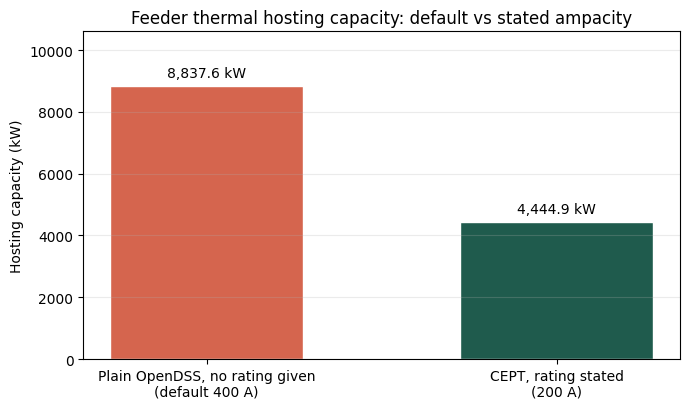

In [6]:
#@title 6. Plot — hosting capacity with and without rating
import matplotlib.pyplot as plt
from IPython.display import display

labels = [
    "Plain OpenDSS, no rating given\n(default 400 A)",
    "CEPT, rating stated\n(200 A)",
]
values = [round(direct_default_kw, 1), cept_hc_kw]
colors = ["#d5654e", "#1f5b4d"]

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.55)
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(values) * 0.02,
        f"{value:,.1f} kW",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_title("Feeder thermal hosting capacity: default vs stated ampacity")
ax.set_ylabel("Hosting capacity (kW)")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
display(fig)
plt.close(fig)


## ✓ Verify — Check the saved run

Verify this exact run directory and its persisted artifacts.

In [7]:
# 7. Verify — check this exact saved run
!cept verify runs/rating-200a --format text


CEPT study check: PASSED
----------------------------
Study              Hosting capacity (OpenDSS)
Case fingerprint   311800109495 (matches the case you ran)

Checked   3 groups, 13 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (2 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json

Next
  cept verify . --physics --format text


## ◇ Interpret — Bound the result

- Plain OpenDSS uses a default 400 A rating when none is given. That is not bad arithmetic. It is an assumption no engineer supplied.
- CEPT refuses the missing rating and requires an explicit value.
- The 4,444.9 kW result is only as good as the declared 200 A rating and feeder impedances.
- This calculation is not a dynamic line rating, equipment capability assessment, or utility interconnection study.